In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
traffic_df = pd.read_csv("../tsf_compare/data/traffic/traffic_with_date.csv")
traffic_df.head()

,date,0,1,2,3,4,5,6,7,8,...,852,853,854,855,856,857,858,859,860,OT
0,2016-07-01 02:00:00,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,...,0.0051,0.0051,0.0074,0.0079,0.0051,0.0051,0.0339,0.0051,0.0100,0.0121
1,2016-07-01 03:00:00,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,...,0.0036,0.0036,0.0107,0.0058,0.0036,0.0036,0.0348,0.0036,0.0087,0.0136
2,2016-07-01 04:00:00,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,...,0.0030,0.0030,0.0043,0.0050,0.0030,0.0030,0.0327,0.0030,0.0061,0.0107
3,2016-07-01 05:00:00,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,...,0.0033,0.0033,0.0019,0.0052,0.0033,0.0033,0.0292,0.0033,0.0040,0.0071
4,2016-07-01 06:00:00,0.0042,0.0055,0.0191,0.0082,0.0024,0.0095,0.0064,0.0087,0.0144,...,0.0049,0.0049,0.0011,0.0071,0.0049,0.0049,0.0264,0.0049,0.0040,0.0039


In [3]:
traffic_df.shape

(17544, 863)

In [4]:
17544//24

731

In [5]:
706*24, 25*24, (706*24+25*24)

(16944, 600, 17544)

### Only using data of 25 days

In [6]:
df = traffic_df.iloc[:25*24, 1:11]
df_raw = df.copy()
df.head()

,0,1,2,3,4,5,6,7,8,9
0,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,0.0375
1,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,0.0381
2,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,0.0309
3,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,0.0199
4,0.0042,0.0055,0.0191,0.0082,0.0024,0.0095,0.0064,0.0087,0.0144,0.0226


In [7]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.574725,-0.509822,-0.901345,-0.838060,-0.489680,-0.363104,-0.692338,-0.393495,-0.300562,-0.327345
1,-0.536756,-0.505999,-0.795039,-0.755339,-0.424857,-0.348283,-0.624122,-0.175574,-0.057150,-0.322816
2,-0.587381,-0.595841,-0.939685,-0.884590,-0.538297,-0.477961,-0.753557,-0.363985,-0.324119,-0.377161
3,-0.588964,-0.674214,-1.025078,-0.972481,-0.603121,-0.574293,-0.821773,-0.572825,-0.640817,-0.460187
4,-0.584217,-0.683772,-1.072132,-0.993161,-0.619326,-0.616902,-0.863752,-0.745346,-0.816179,-0.439808


### Smoothing using rolling mean

In [8]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [9]:
import math

SPLIT_RATIO = 0.8
TOTAL_POINTS = len(df)
PERIOD = 25
TRAIN_DAYS = math.ceil(PERIOD * SPLIT_RATIO)
TEST_DAYS = PERIOD - TRAIN_DAYS
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")
print(f"Train days: {TRAIN_DAYS}, Test days: {TEST_DAYS}")

Tensor dimensions: 25 x 24 x 10
Train days: 20, Test days: 5


In [10]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 10)

In [11]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 10)
Test tensor shape: (5, 24, 10)


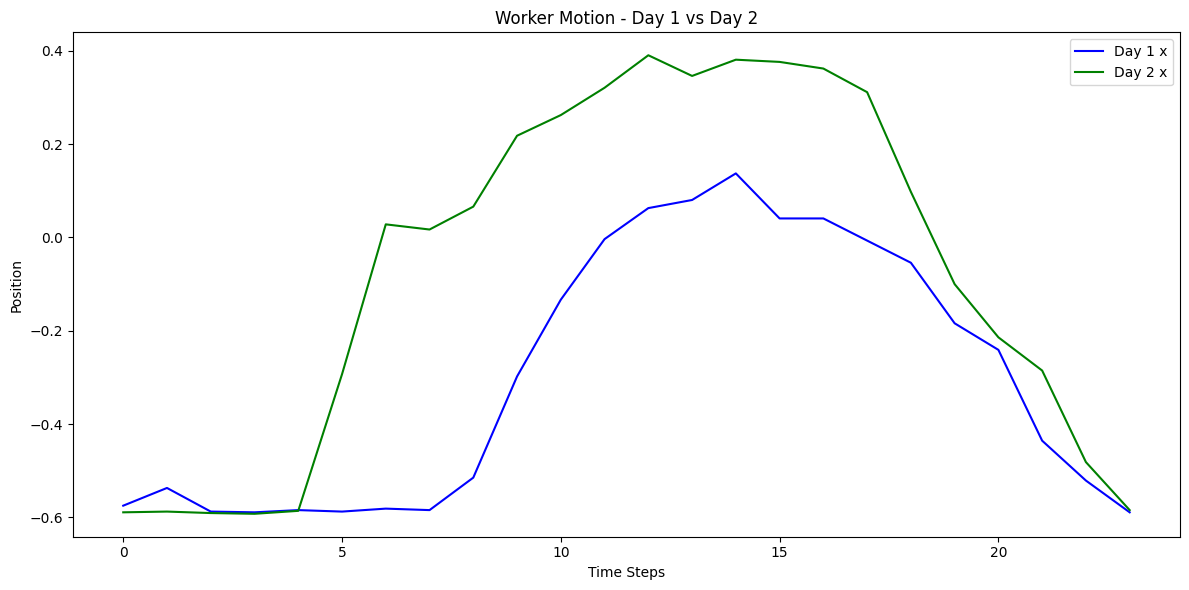

In [12]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[1, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [13]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (10, 2)


In [14]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 10)
Reconstructed tensor shape: (20, 24, 10)


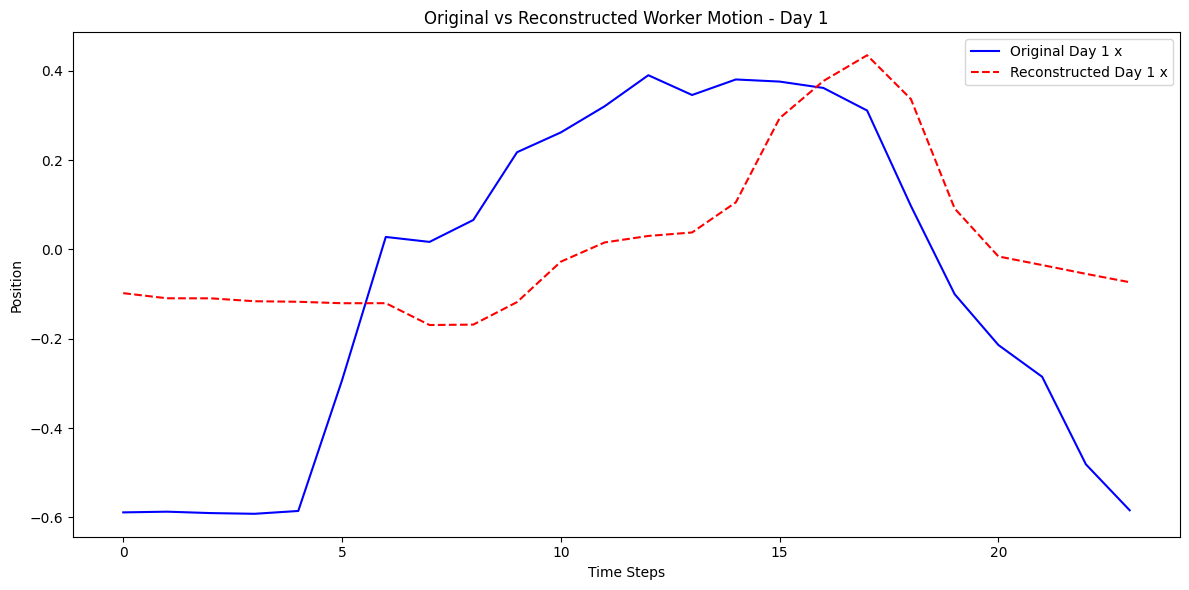

In [15]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [16]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

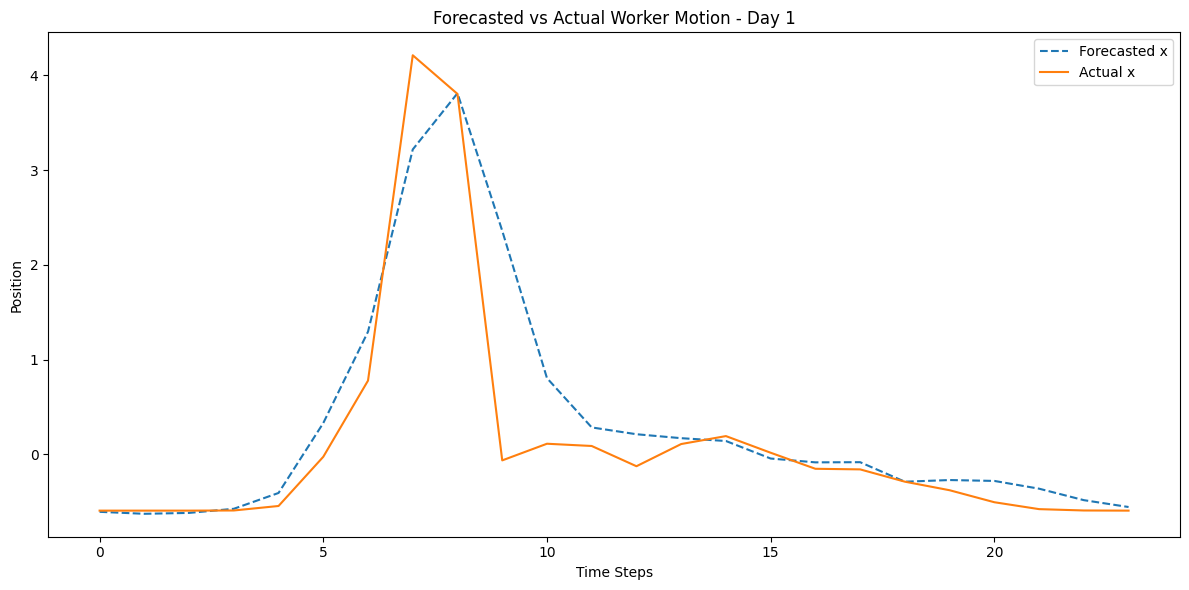

In [17]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

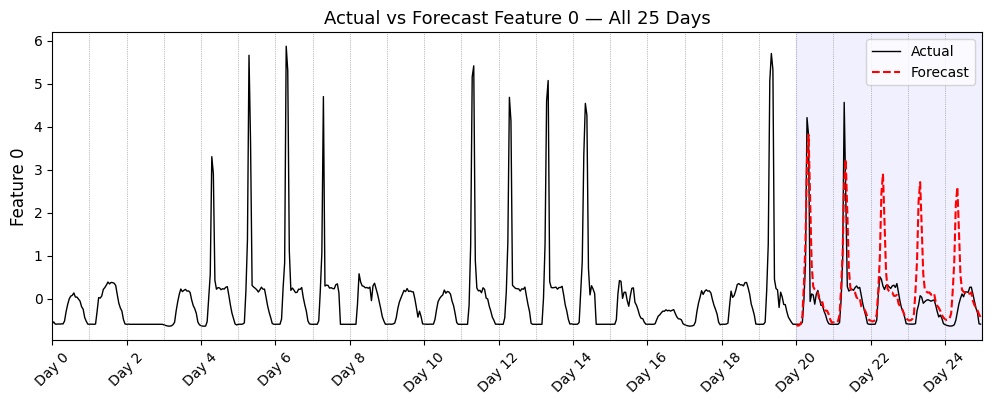

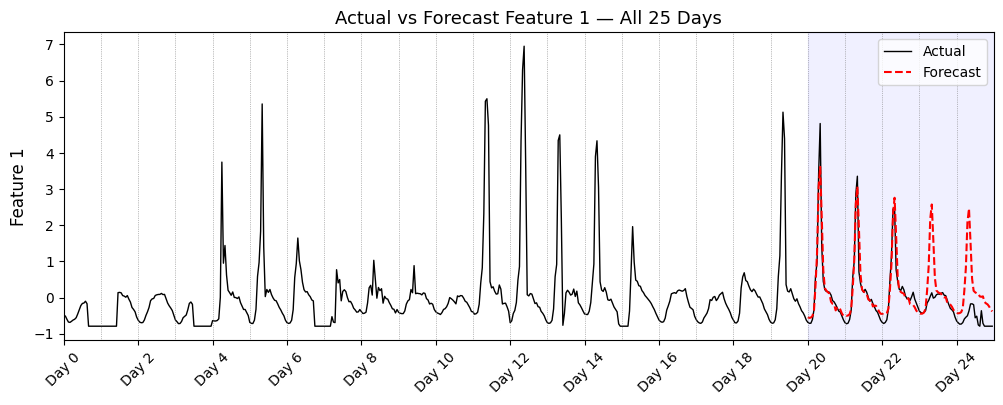

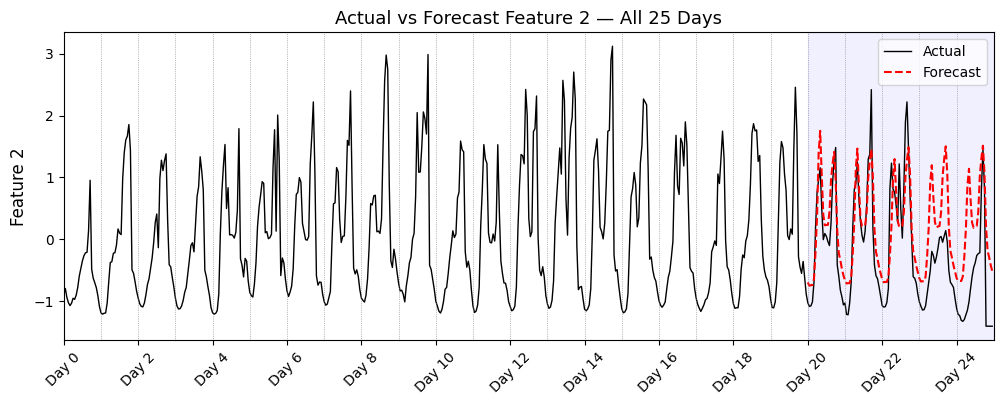

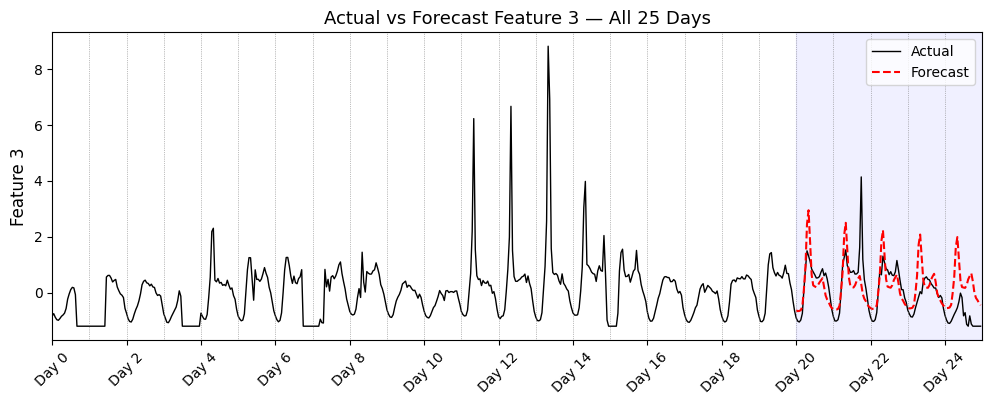

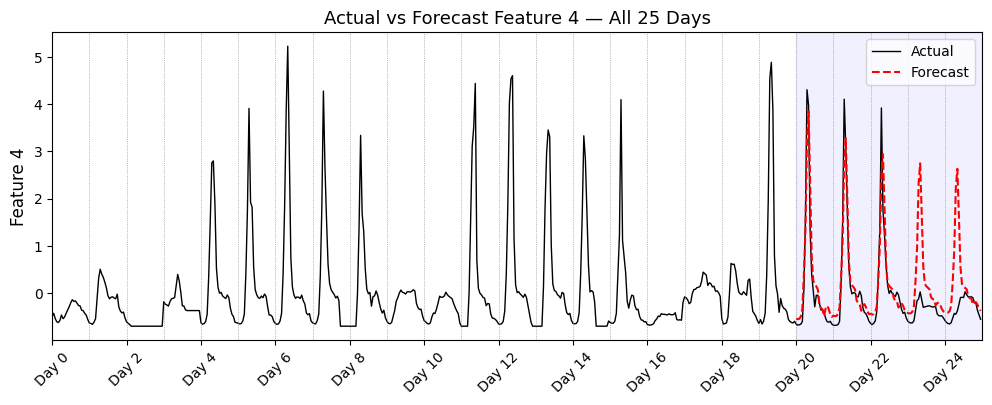

In [18]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

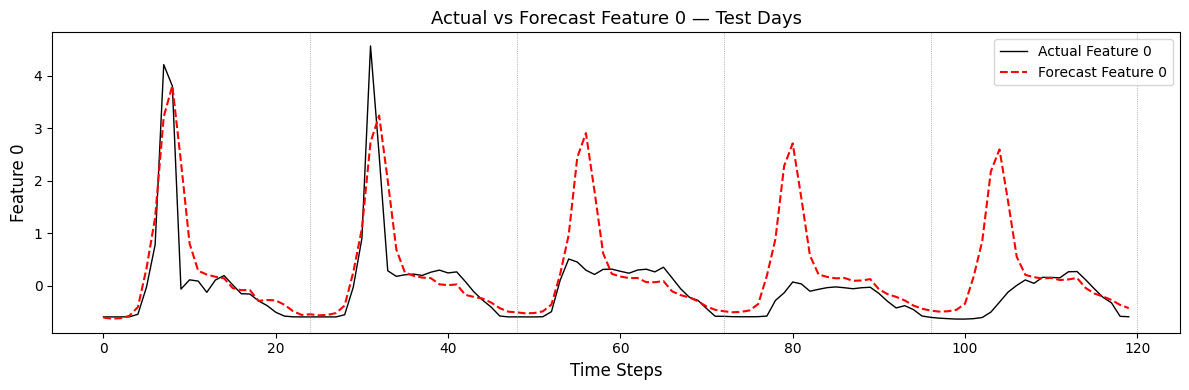

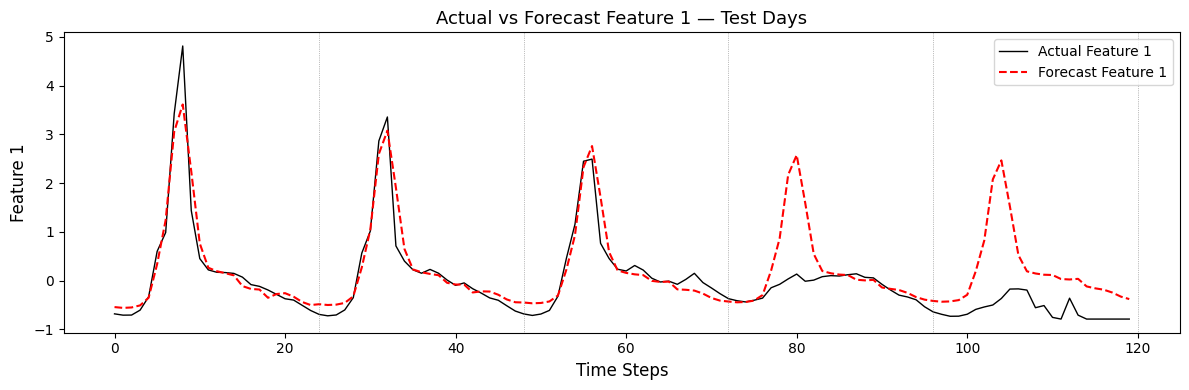

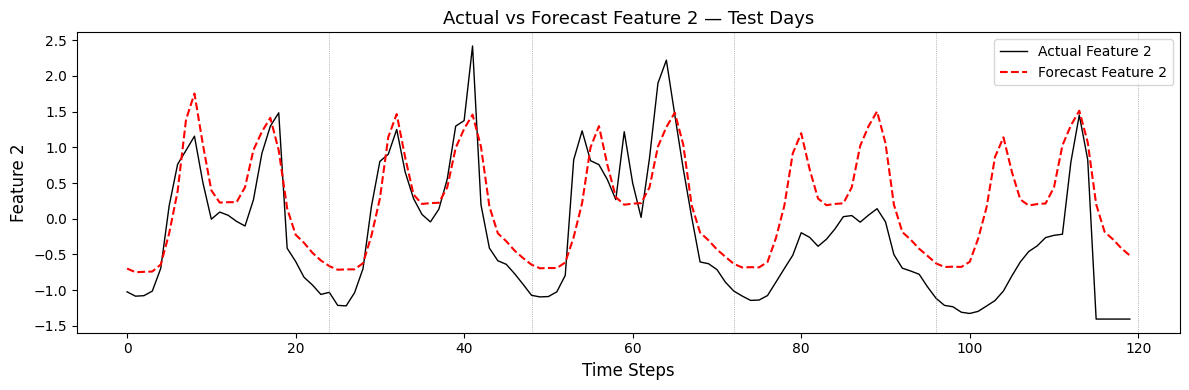

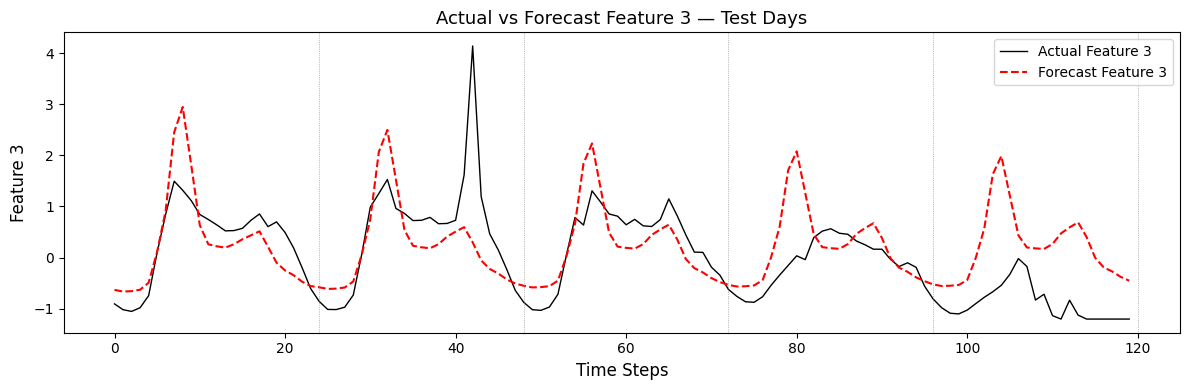

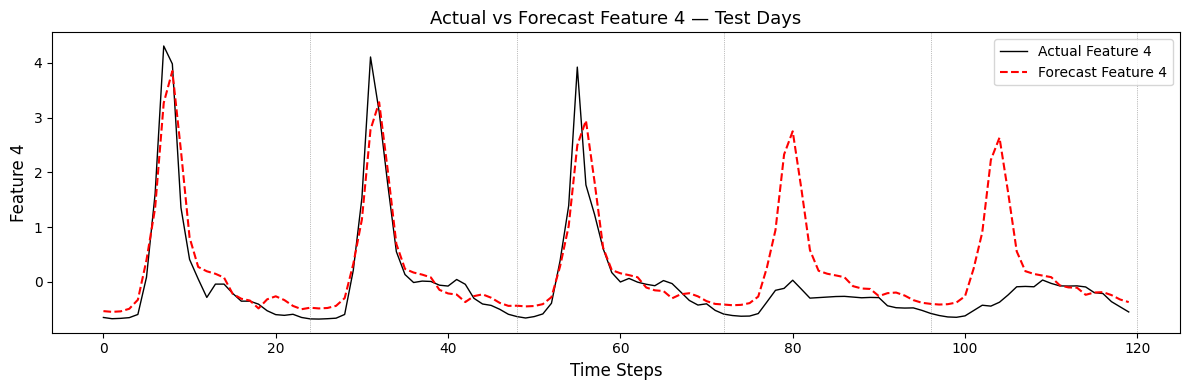

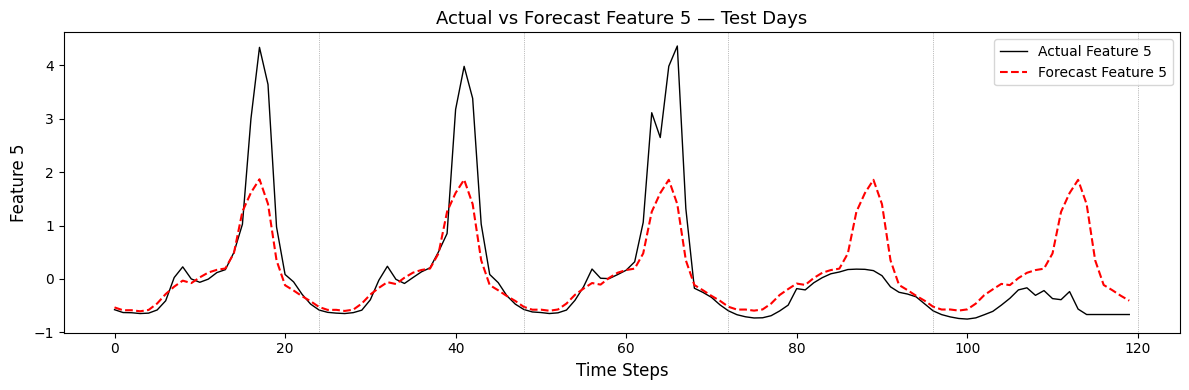

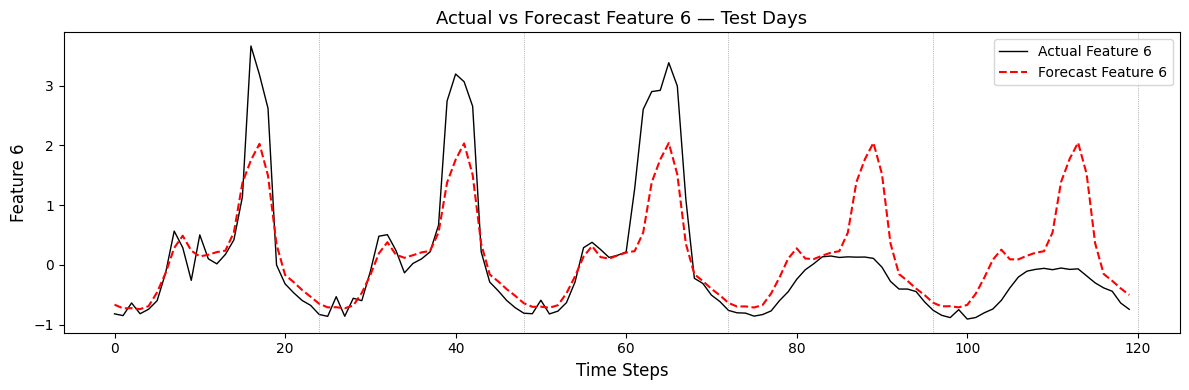

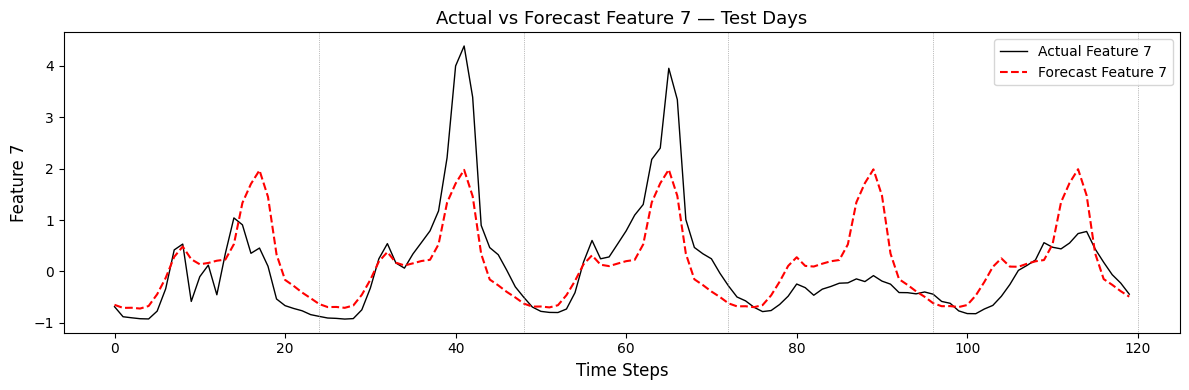

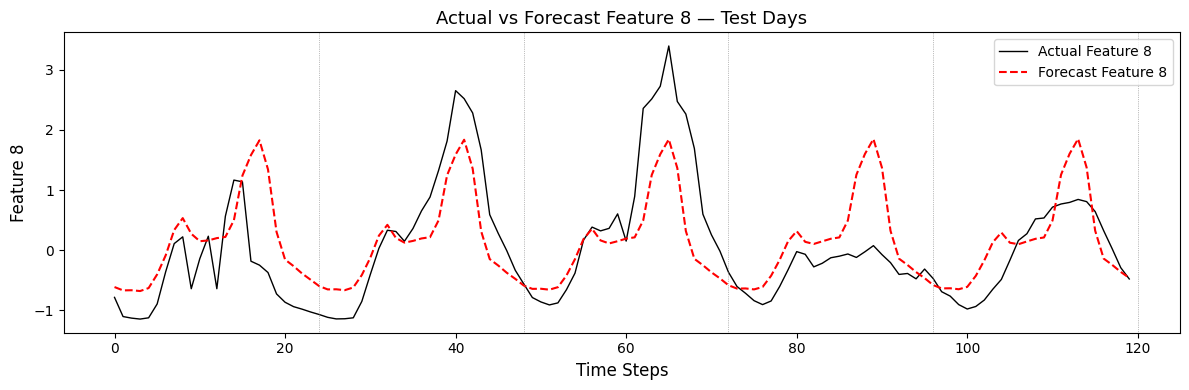

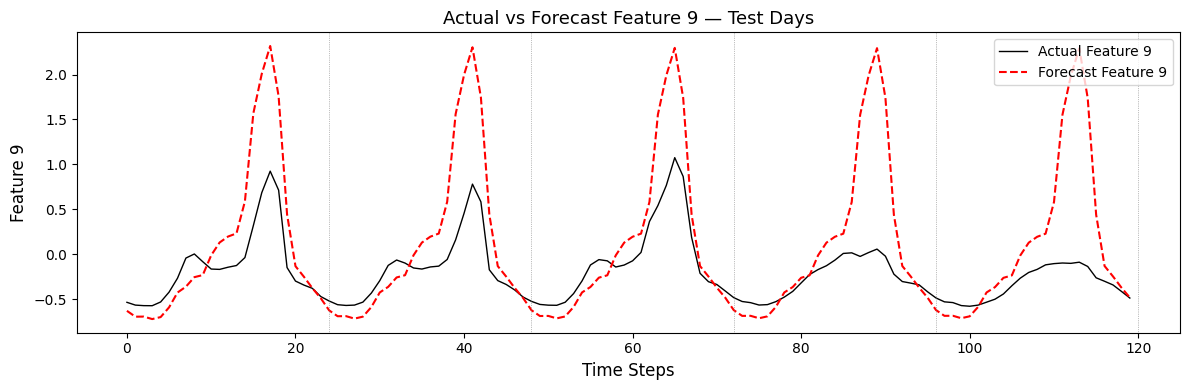

In [19]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(10):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [20]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 10), (120, 10))

In [21]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: 0.1025, MSE: 0.5830, MAE: 0.3958, RMSE: 0.7635
Feature 1 R²: 0.5044, MSE: 0.3901, MAE: 0.3475, RMSE: 0.6246
Feature 2 R²: 0.4088, MSE: 0.4721, MAE: 0.5560, RMSE: 0.6871
Feature 3 R²: 0.1021, MSE: 0.6973, MAE: 0.6005, RMSE: 0.8350
Feature 4 R²: 0.5190, MSE: 0.4471, MAE: 0.3716, RMSE: 0.6687
Feature 5 R²: 0.5337, MSE: 0.6106, MAE: 0.4311, RMSE: 0.7814
Feature 6 R²: 0.6012, MSE: 0.4676, MAE: 0.4306, RMSE: 0.6838
Feature 7 R²: 0.5109, MSE: 0.5194, MAE: 0.4987, RMSE: 0.7207
Feature 8 R²: 0.4674, MSE: 0.5146, MAE: 0.5376, RMSE: 0.7173
Feature 9 R²: -2.7072, MSE: 0.4660, MAE: 0.4148, RMSE: 0.6826
average R²: 0.1043, average MSE: 0.5168, average MAE: 0.4584, average RMSE: 0.7165
